In [10]:
import sys
sys.path.append('../../../..')

In [11]:
from bridge.nloader import *


In [22]:
import torch
from mmseg.models import build_segmentor
from mmengine.config import Config
from mmengine.runner import Runner
from torchinfo import summary
from fvcore.nn import FlopCountAnalysis, flop_count_table

from torchview import draw_graph

In [23]:
def get_network(self, config):
        cfg = Config.fromfile(config)
        model = build_segmentor(
            cfg.model,
            train_cfg=cfg.get('train_cfg'),
            test_cfg=cfg.get('test_cfg')).cuda()
        cfg.log_config['hooks'] = [
            dict(type='TextLoggerHook', by_epoch=False),
        ]
        model.eval()

        model.forward = model.forward_dummy

        return model

In [24]:
def summarize_network(config, image_shape, transformer=False, viz=False):
        cfg = Config.fromfile(config)
        cfg.model.pretrained = None

        model = build_segmentor(
            cfg.model,
            train_cfg=cfg.get('train_cfg'),
            test_cfg=cfg.get('test_cfg')).cuda()
        model.eval()
        model.forward = model.forward_dummy

        if not transformer:
            print(summary(model, (1, 3, image_shape[0], image_shape[1])))
        else:
            inputs = (torch.randn((1, 3, image_shape[0], image_shape[1])).to('cuda'),)

            # flops, params = get_model_complexity_info(model, input_shape)
            flops = FlopCountAnalysis(model, inputs)
            print(flop_count_table(flops))
            print('{:<30}  {:<8}'.format('FLOPs: ', flops.total()))

        return

        if viz:
            y = model(inputs[0])
            make_dot(y, params=dict(list(model.named_parameters()) + [('x', inputs[0])]))

            print('{:<30}  {:<8}'.format('FLOPs: ', flops.total()))
            returns

In [25]:
# cfg = Config.fromfile('segformer_mit-b0_8xb2-160k_methane-512x512.py')

config = 'segformer_mit-b0_8xb2-160k_methane-512x512.py'

image_shape = (512, 512)


In [26]:
cfg = Config.fromfile(config)
cfg.model.pretrained = None
cfg.model.data_preprocessor = None



In [27]:
model = build_segmentor(
            cfg.model,
            train_cfg=None,
            test_cfg=None).cuda()

In [28]:
model.eval()
# model.forward = model.forward_dummy

EncoderDecoder(
  (data_preprocessor): BaseDataPreprocessor()
  (backbone): MixVisionTransformer(
    (layers): ModuleList(
      (0): ModuleList(
        (0): PatchEmbed(
          (projection): Conv2d(3, 32, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (norm): LayerNorm((32,), eps=1e-06, elementwise_affine=True)
        )
        (1): ModuleList(
          (0-1): 2 x TransformerEncoderLayer(
            (norm1): LayerNorm((32,), eps=1e-06, elementwise_affine=True)
            (attn): EfficientMultiheadAttention(
              (attn): MultiheadAttention(
                (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
              )
              (proj_drop): Dropout(p=0.0, inplace=False)
              (dropout_layer): DropPath()
              (sr): Conv2d(32, 32, kernel_size=(8, 8), stride=(8, 8))
              (norm): LayerNorm((32,), eps=1e-06, elementwise_affine=True)
            )
            (norm2): LayerNorm((32,), eps=1e

In [29]:
inputs = (torch.randn((1, 3, image_shape[0], image_shape[1])).to('cuda'),)
model(inputs[0])



tensor([[[[-0.1201, -0.4515, -0.1118,  ...,  0.2798, -0.1073, -0.0272],
          [-0.3711, -0.0586,  0.3467,  ...,  0.0790,  0.0100, -0.1490],
          [ 0.0618,  0.1776,  0.0078,  ...,  0.1536, -0.0599, -0.3948],
          ...,
          [ 0.3883,  0.6259,  0.4842,  ..., -0.5252, -0.5038, -0.3874],
          [ 0.2804,  0.3131,  0.4159,  ..., -0.6176, -0.6046, -0.5318],
          [ 0.4308,  0.2789, -0.0928,  ..., -0.8171, -0.3350, -0.4925]],

         [[ 0.8864,  0.5445,  0.5986,  ...,  0.5046, -0.0197,  0.1242],
          [ 0.3831,  0.4925,  0.5838,  ...,  0.4835,  0.2098, -0.0287],
          [ 0.8730,  0.5657,  0.4130,  ...,  1.0132,  0.3729,  0.4488],
          ...,
          [ 1.0941,  0.8077,  0.6013,  ...,  1.0803,  1.2827,  1.5545],
          [ 1.0207,  0.8042,  1.0440,  ...,  0.9034,  1.1531,  1.2161],
          [ 0.6954,  1.1647,  0.8008,  ...,  0.9018,  0.8249,  0.8888]],

         [[ 0.0379, -0.1506, -0.2554,  ...,  0.1092, -0.0717, -0.0736],
          [-0.3029, -0.3862, -


(process:13068): Pango-WARNING **: 10:02:46.925: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


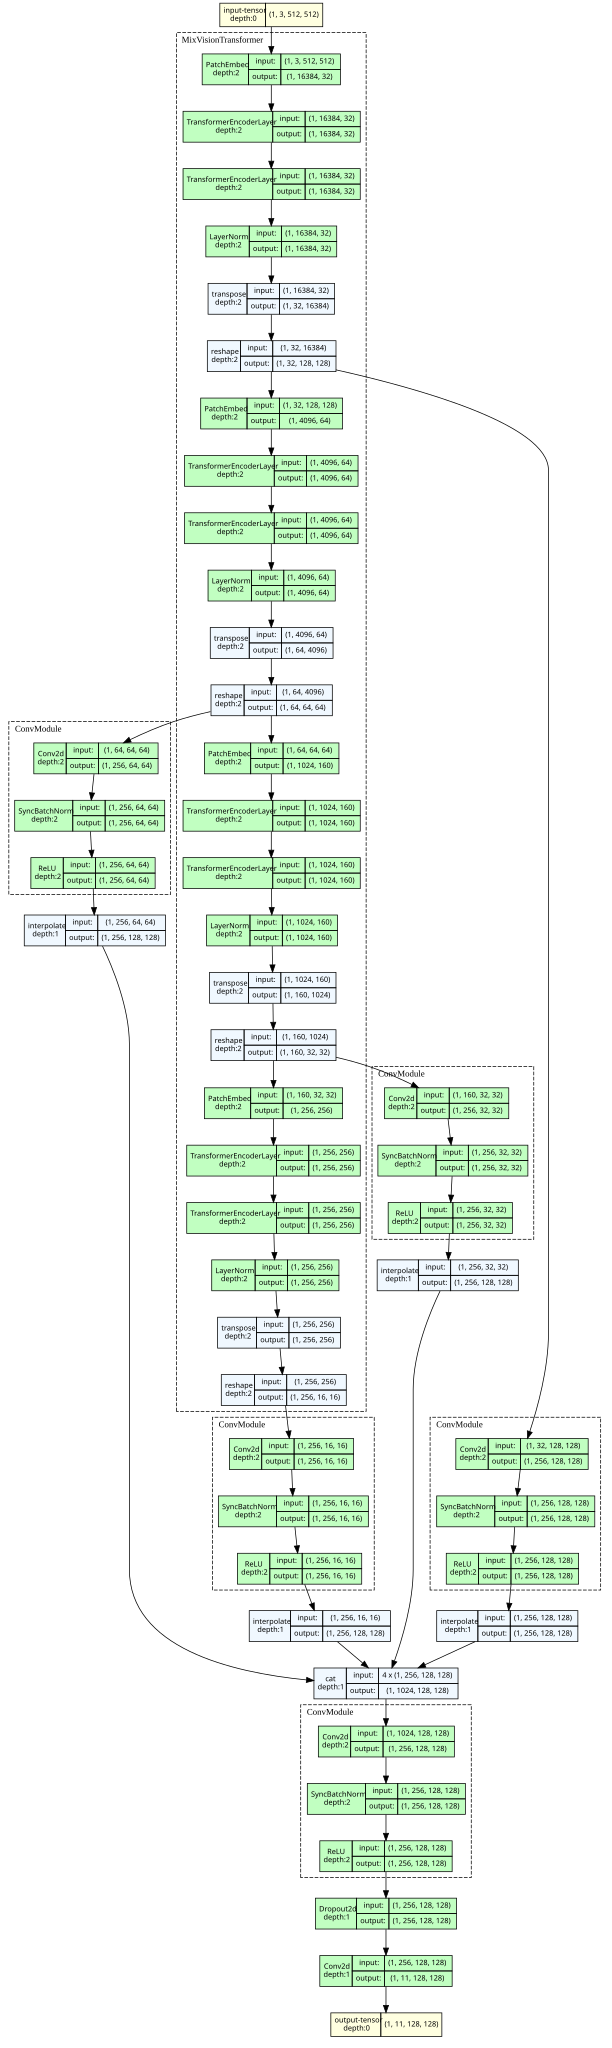

In [30]:
# device='meta' -> no memory is consumed for visualization
model_graph = draw_graph(model, input_size=(1, 3, 512, 512), depth=2, expand_nested=True, graph_dir='TB')
model_graph.visual_graph

In [53]:
flops = FlopCountAnalysis(model, inputs)
print(flop_count_table(flops))
print('{:<30}  {:<8}'.format('FLOPs: ', flops.total()))


| module                          | #parameters or shape   | #flops     |
|:--------------------------------|:-----------------------|:-----------|
| model                           | 3.718M                 | 9.494G     |
|  backbone.layers                |  3.319M                |  4G        |
|   backbone.layers.0             |   0.164M               |   1.324G   |
|    backbone.layers.0.0          |    4.8K                |    93.389M |
|    backbone.layers.0.1          |    0.159M              |    1.228G  |
|    backbone.layers.0.2          |    64                  |    3.072M  |
|   backbone.layers.1             |   0.255M               |   0.926G   |
|    backbone.layers.1.0          |    18.624K             |    90.01M  |
|    backbone.layers.1.1          |    0.237M              |    0.835G  |
|    backbone.layers.1.2          |    0.128K              |    1.536M  |
|   backbone.layers.2             |   0.93M                |   1.068G   |
|    backbone.layers.2.0          |   

In [54]:
print(summary(model, (1, 3, image_shape[0], image_shape[1])))

Layer (type:depth-idx)                                            Output Shape              Param #
EncoderDecoder                                                    [1, 11, 160, 120]         --
├─MixVisionTransformer: 1-1                                       [1, 32, 160, 120]         --
│    └─ModuleList: 2-1                                            --                        --
│    │    └─ModuleList: 3-1                                       --                        164,096
│    │    └─ModuleList: 3-2                                       --                        255,296
│    │    └─ModuleList: 3-3                                       --                        930,080
│    │    └─ModuleList: 3-4                                       --                        1,969,920
├─SegformerHead: 1-2                                              --                        --
│    └─ModuleList: 2-2                                            --                        --
│    │    └─ConvModule:

In [4]:
bridge = GlobalBridgeController()

baseline_config = bridge.MMSegConfig(
    model_name='segformer',
    config_file='segformer_mit-b0_8xb2-160k_methane-512x512.py',
    # checkpoint_url='http://vmv.re/q4OtB'
)


In [9]:
bridge.summarize_network(
    baseline_config.config_file, image_shape)

d:\toqi\opt\mmsegmentation\mmseg\models\builder.py:36: UserWarning: ``build_loss`` would be deprecated soon, please use ``mmseg.registry.MODELS.build()`` 
  warnings.warn('``build_loss`` would be deprecated soon, please use '
d:\toqi\opt\mmsegmentation\mmseg\models\losses\cross_entropy_loss.py:249: UserWarning: Default ``avg_non_ignore`` is False, if you would like to ignore the certain label and average loss over non-ignore labels, which is the same with PyTorch official cross_entropy, set ``avg_non_ignore=True``.
  warnings.warn(


Layer (type:depth-idx)                                            Output Shape              Param #
EncoderDecoder                                                    [1, 11, 160, 120]         --
├─MixVisionTransformer: 1-1                                       [1, 32, 160, 120]         --
│    └─ModuleList: 2-1                                            --                        --
│    │    └─ModuleList: 3-1                                       --                        164,096
│    │    └─ModuleList: 3-2                                       --                        255,296
│    │    └─ModuleList: 3-3                                       --                        930,080
│    │    └─ModuleList: 3-4                                       --                        1,969,920
├─SegformerHead: 1-2                                              --                        --
│    └─ModuleList: 2-2                                            --                        --
│    │    └─ConvModule:

In [10]:
bridge.summarize_network(baseline_config.config_file, image_shape, transformer=True)

d:\toqi\opt\mmsegmentation\mmseg\models\builder.py:36: UserWarning: ``build_loss`` would be deprecated soon, please use ``mmseg.registry.MODELS.build()`` 
  warnings.warn('``build_loss`` would be deprecated soon, please use '
d:\toqi\opt\mmsegmentation\mmseg\models\losses\cross_entropy_loss.py:249: UserWarning: Default ``avg_non_ignore`` is False, if you would like to ignore the certain label and average loss over non-ignore labels, which is the same with PyTorch official cross_entropy, set ``avg_non_ignore=True``.
  warnings.warn(


| module                          | #parameters or shape   | #flops     |
|:--------------------------------|:-----------------------|:-----------|
| model                           | 3.718M                 | 9.494G     |
|  backbone.layers                |  3.319M                |  4G        |
|   backbone.layers.0             |   0.164M               |   1.324G   |
|    backbone.layers.0.0          |    4.8K                |    93.389M |
|    backbone.layers.0.1          |    0.159M              |    1.228G  |
|    backbone.layers.0.2          |    64                  |    3.072M  |
|   backbone.layers.1             |   0.255M               |   0.926G   |
|    backbone.layers.1.0          |    18.624K             |    90.01M  |
|    backbone.layers.1.1          |    0.237M              |    0.835G  |
|    backbone.layers.1.2          |    0.128K              |    1.536M  |
|   backbone.layers.2             |   0.93M                |   1.068G   |
|    backbone.layers.2.0          |   